# 🏠 House Price Prediction

## Phase 2 - Train, Evaluate, and Export the Machine Learning Model

### Project Objective
The objective of this project is to build a complete machine learning pipeline for predicting house prices using a real estate dataset from Kaggle.

The notebook includes:

- Loading and inspecting the dataset.
- Exploratory Data Analysis (EDA).
- Data cleaning and feature engineering.
- Building and comparing multiple regression models.
- Evaluating model performance.
- Exporting the best trained model for deployment.

---

In [1]:
# ===========================
# Import Required Libraries
# ===========================

import warnings
warnings.filterwarnings("ignore")

import re
import json
import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LinearRegression

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

# ## Load the Dataset

In this section, we load the dataset into a pandas DataFrame and inspect its overall structure before performing any preprocessing.


In [2]:
# Load Dataset

df = pd.read_csv("house_prices.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [3]:
# Display Dataset Shape

print("Shape of Dataset:")
print(df.shape)

Shape of Dataset:
(185409, 21)


In [4]:
# Display First Five Rows

df.head()

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [5]:
# Display Column Names

df.columns.tolist()

['Index',
 'Title',
 'Description',
 'Amount(in rupees)',
 'Price (in rupees)',
 'location',
 'Carpet Area',
 'Status',
 'Floor',
 'Transaction',
 'Furnishing',
 'facing',
 'overlooking',
 'Society',
 'Bathroom',
 'Balcony',
 'Car Parking',
 'Ownership',
 'Super Area',
 'Dimensions',
 'Plot Area']

In [6]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185409 entries, 0 to 185408
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              185409 non-null  int64  
 1   Title              185409 non-null  object 
 2   Description        182403 non-null  object 
 3   Amount(in rupees)  185409 non-null  object 
 4   Price (in rupees)  167882 non-null  float64
 5   location           185409 non-null  object 
 6   Carpet Area        105386 non-null  object 
 7   Status             184796 non-null  object 
 8   Floor              178366 non-null  object 
 9   Transaction        185331 non-null  object 
 10  Furnishing         182528 non-null  object 
 11  facing             115695 non-null  object 
 12  overlooking        104603 non-null  object 
 13  Society            76710 non-null   object 
 14  Bathroom           184594 non-null  object 
 15  Balcony            136780 non-null  object 
 16  Ca

In [7]:
# Statistical Summary

df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Index,185409.0,NaN,NaN,NaN,92704.0,53523.112367,0.0,46352.0,92704.0,139056.0,185408.0
Title,185409,31948,2 BHK Ready to Occupy Flat for sale in Divyasr...,2106,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,182403,63529,Multistorey apartment is available for sale. I...,2732,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Amount(in rupees),185409,1561,Call for Price,9607,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price (in rupees),167882.0,NaN,NaN,NaN,7621.700212,27399.520829,0.0,4335.0,6047.0,9560.0,6700000.0
location,185409,79,new-delhi,27599,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Carpet Area,105386,2746,1000 sqft,5223,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Status,184796,1,Ready to Move,184796,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Floor,178366,946,2 out of 4,12256,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transaction,185331,4,Resale,142908,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# ## Missing Values Analysis

The following section calculates the percentage of missing values for each column in the dataset.

This helps identify which features require cleaning or imputation before model training.


In [8]:
# Missing Values Percentage

missing_values = (
    df.isnull()
      .mean()
      .sort_values(ascending=False)
      *100
)

missing_values.to_frame(name="Missing Percentage")

,Missing Percentage
Plot Area,100.000000
Dimensions,100.000000
Society,58.626604
Super Area,57.283627
Car Parking,55.160753
overlooking,43.582566
Carpet Area,43.160257
facing,37.600116
Ownership,35.064102
Balcony,26.227961


In [9]:
# Display Only Columns with Missing Values

missing_values[missing_values > 0]

,0
Plot Area,100.000000
Dimensions,100.000000
Society,58.626604
Super Area,57.283627
Car Parking,55.160753
overlooking,43.582566
Carpet Area,43.160257
facing,37.600116
Ownership,35.064102
Balcony,26.227961


# ## Dataset Inspection Summary

After inspecting the dataset, answer the following questions:

### **1. How many rows and columns does the dataset contain?**

The dataset shape is obtained using:

`df.shape`

---

### **2. Which columns are numeric and which are categorical?**

The data types are identified using:

`df.info()`

- Numerical columns include features with integer or float data types.
- Categorical columns include features stored as object (text).

---

### **3. Which columns contain the highest percentage of missing values?**

The missing value percentages are calculated using:

`df.isnull().mean().sort_values(ascending=False)`

These columns will require appropriate preprocessing during the data cleaning phase.


# ## Exploratory Data Analysis (EDA)

Before building machine learning models, we perform Exploratory Data Analysis (EDA) to better understand the dataset.

The objectives are:

- Convert the target price into a numeric feature.
- Explore the distribution of house prices.
- Study the relationship between price and property area.
- Identify the locations with the highest average prices.
- Analyze how furnishing status and bathrooms affect house prices.


In [10]:
# ===========================
# Convert Price to Numeric
# ===========================

def parse_amount(x):

    if pd.isna(x):
        return np.nan

    x = str(x).strip().lower().replace(",", "")

    if "call for price" in x:
        return np.nan

    try:
        if "lac" in x:
            return float(re.findall(r"[\d.]+", x)[0]) * 100000

        elif "cr" in x:
            return float(re.findall(r"[\d.]+", x)[0]) * 10000000

        else:
            return float(re.findall(r"[\d.]+", x)[0])

    except:
        return np.nan


df["price_clean"] = df["Amount(in rupees)"].apply(parse_amount)

df = df.dropna(subset=["price_clean"])

print("Remaining Rows:", len(df))

Remaining Rows: 175802


# ### Distribution of House Prices

This histogram illustrates the distribution of house prices after converting them into numerical values.

A logarithmic scale is used because house prices are highly skewed.


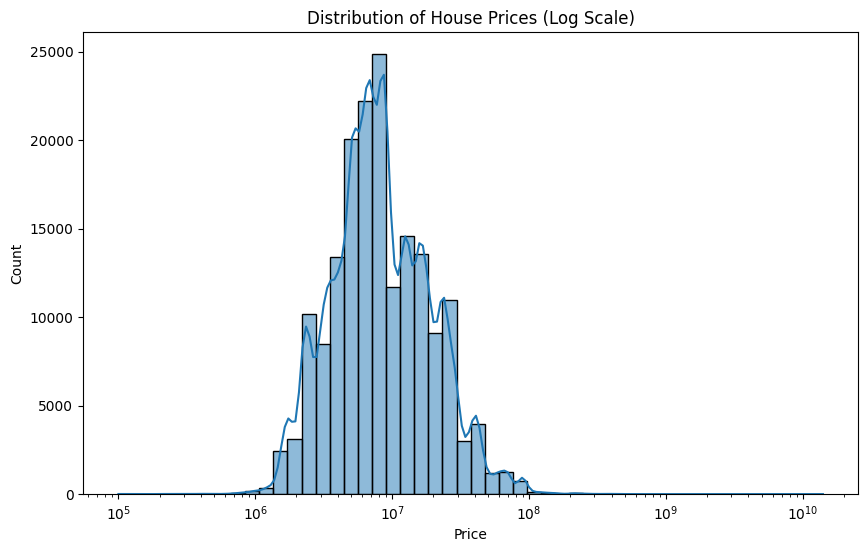

In [11]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="price_clean",
    bins=50,
    log_scale=True,
    kde=True
)

plt.title("Distribution of House Prices (Log Scale)")
plt.xlabel("Price")
plt.ylabel("Count")

plt.show()

### Observation

- The target variable is highly right-skewed.
- Most properties belong to the lower and middle price ranges.
- Only a small number of houses have extremely high prices.
- Using a logarithmic scale makes the distribution easier to interpret.


In [12]:
# ===========================
# Extract Carpet Area (sqft)
# ===========================

def extract_area(area):

    if pd.isna(area):
        return np.nan

    area = str(area).lower()

    number = re.findall(r"[\d.]+", area)

    if len(number)==0:
        return np.nan

    value = float(number[0])

    if "sqm" in area:
        value *= 10.764

    return value


df["carpet_area_sqft"] = df["Carpet Area"].apply(extract_area)

# ### Price vs Carpet Area

This scatter plot illustrates the relationship between house prices and carpet area.


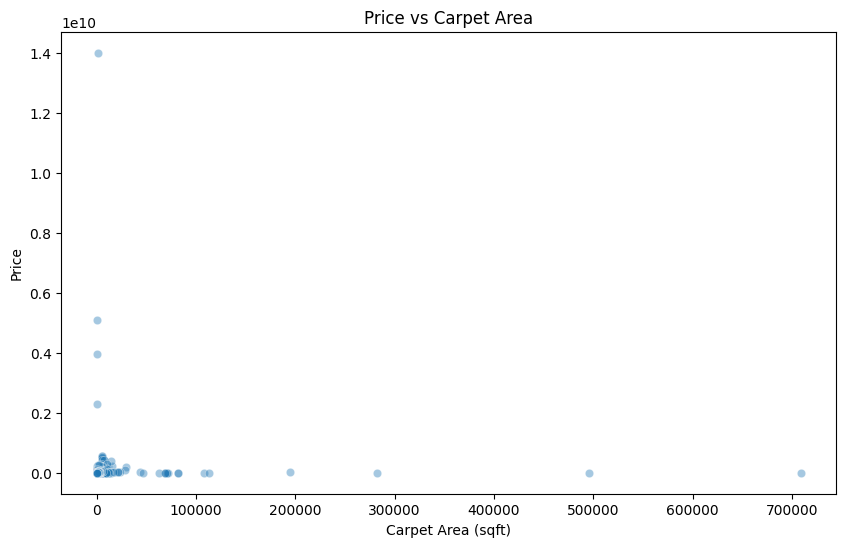

In [13]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="carpet_area_sqft",
    y="price_clean",
    alpha=0.4
)

plt.title("Price vs Carpet Area")

plt.xlabel("Carpet Area (sqft)")
plt.ylabel("Price")

plt.show()

### Observation

- Larger houses generally have higher prices.
- Some outliers exist with unusually high prices.
- The relationship appears positively correlated.


In [14]:
top_locations = (

    df.groupby("location")["price_clean"]

    .mean()

    .sort_values(ascending=False)

    .head(15)

)

top_locations

,price_clean
location,
mumbai,3.355292e+07
gurgaon,2.170470e+07
siliguri,1.803144e+07
panchkula,1.712139e+07
raipur,1.638794e+07
new-delhi,1.616784e+07
hyderabad,1.526815e+07
chennai,1.139704e+07
noida,1.122650e+07


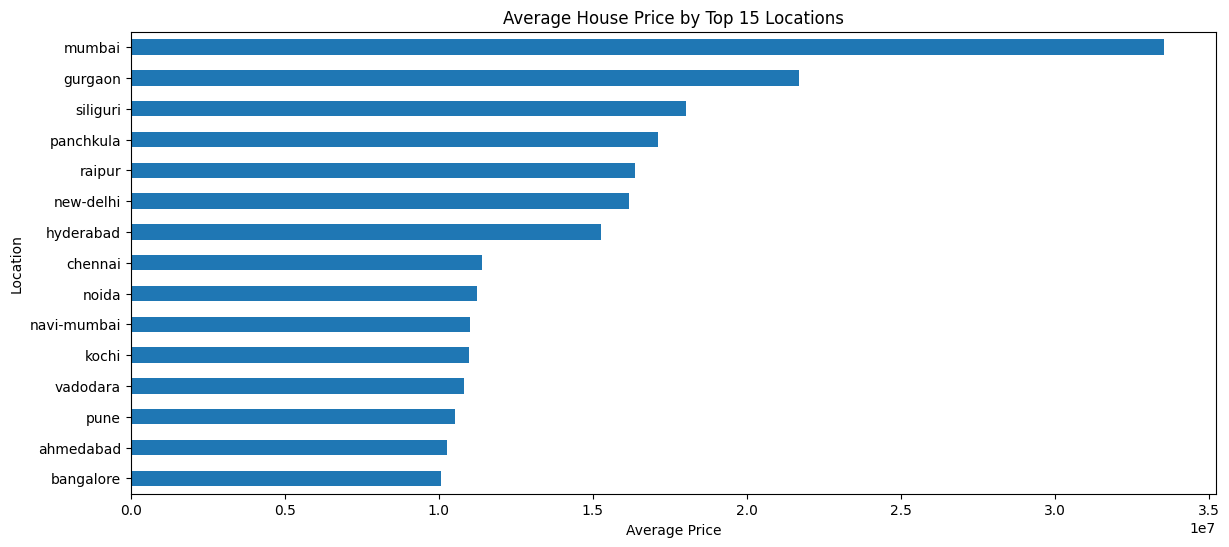

In [15]:
plt.figure(figsize=(14,6))

top_locations.sort_values().plot(kind="barh")

plt.title("Average House Price by Top 15 Locations")

plt.xlabel("Average Price")

plt.ylabel("Location")

plt.show()

### Observation

- Property prices vary significantly across different locations.
- Premium locations have substantially higher average prices.
- Location is expected to be one of the most important predictive features.


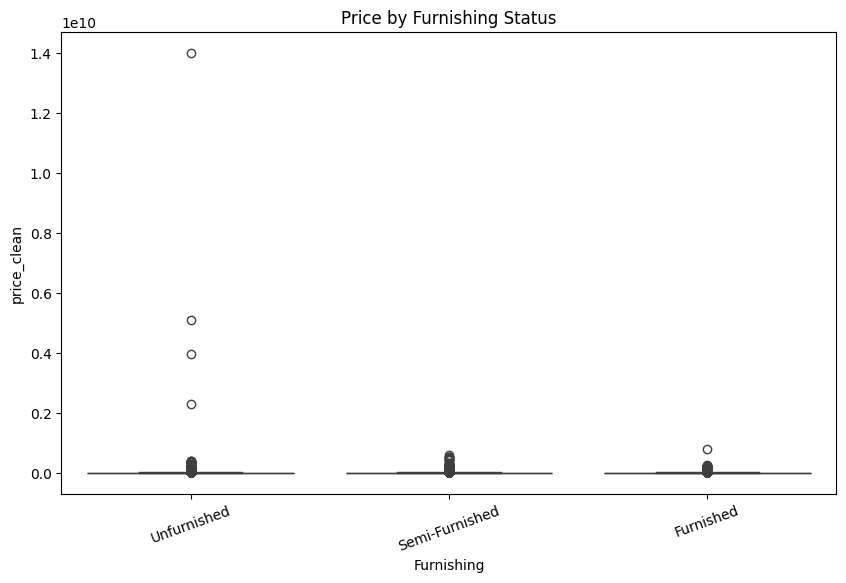

In [16]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Furnishing",
    y="price_clean"
)

plt.xticks(rotation=20)

plt.title("Price by Furnishing Status")

plt.show()

### Observation

- Furnished properties generally have higher prices.
- Semi-furnished houses occupy the middle range.
- Unfurnished properties tend to be the least expensive.


In [17]:
# Convert Bathroom to numeric

df["bathroom"] = (

    df["Bathroom"]

    .astype(str)

    .str.extract(r"(\d+)")

    .astype(float)

)

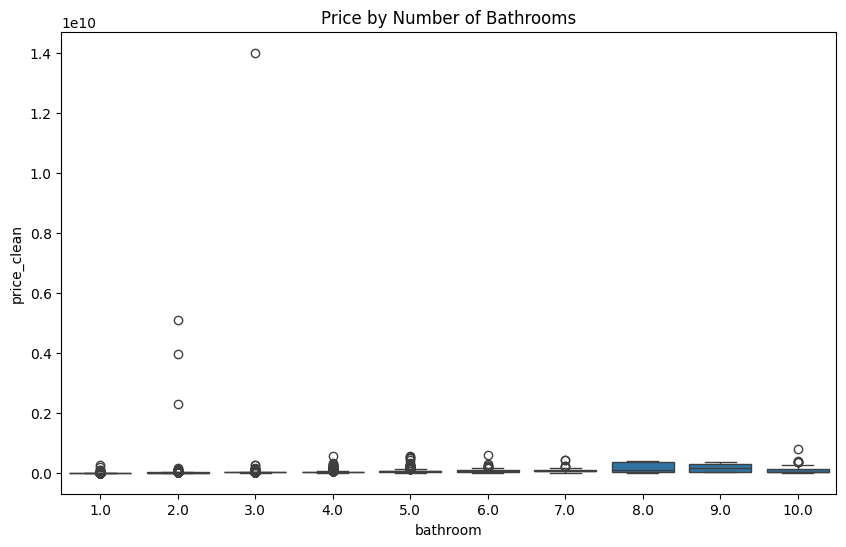

In [18]:
plt.figure(figsize=(10,6))

sns.boxplot(

    data=df,

    x="bathroom",

    y="price_clean"

)

plt.title("Price by Number of Bathrooms")

plt.show()

### Observation

- Houses with more bathrooms generally have higher prices.
- The price tends to increase as the number of bathrooms increases.
- A few extreme outliers are visible and will be handled during preprocessing.


# ## Data Cleaning & Feature Engineering

In this section, we prepare the dataset for machine learning by:

- Cleaning inconsistent values.
- Extracting useful numerical features.
- Handling missing values.
- Grouping high-cardinality categorical variables.
- Removing unrealistic outliers.

These preprocessing steps improve model performance and generalization.


In [19]:
# ===========================
# Extract Floor Number
# ===========================

def extract_floor(value):

    if pd.isna(value):
        return np.nan

    value = str(value).lower()

    if "ground" in value:
        return 0

    if "basement" in value:
        return -1

    number = re.findall(r"\d+", value)

    if len(number) > 0:
        return int(number[0])

    return np.nan


df["floor_num"] = df["Floor"].apply(extract_floor)

In [20]:
# ===========================
# Convert Bathroom, Balcony,
# and Car Parking to Numeric
# ===========================

def extract_number(value):

    if pd.isna(value):
        return np.nan

    number = re.findall(r"\d+", str(value))

    if len(number) == 0:
        return np.nan

    return int(number[0])


df["bathroom"] = df["Bathroom"].apply(extract_number)

df["balcony"] = df["Balcony"].apply(extract_number)

df["car_parking"] = df["Car Parking"].apply(extract_number)

In [21]:
# Fill Missing Numerical Values

df["bathroom"] = df["bathroom"].fillna(df["bathroom"].median())

df["balcony"] = df["balcony"].fillna(0)

df["car_parking"] = df["car_parking"].fillna(0)

df["floor_num"] = df["floor_num"].fillna(df["floor_num"].median())

df["carpet_area_sqft"] = df["carpet_area_sqft"].fillna(
    df["carpet_area_sqft"].median()
)

# ### Group High-Cardinality Locations

The **location** feature contains a large number of unique values.

To reduce dimensionality during one-hot encoding, only the top 50 most frequent locations are kept, while all remaining locations are grouped into **"Other"**.


In [22]:
# Keep Top 50 Locations

top_locations = df["location"].value_counts().head(50).index

df["location_grouped"] = df["location"].apply(
    lambda x: x if x in top_locations else "Other"
)

In [23]:
# Fill Missing Categorical Values

categorical_columns = [
    "Furnishing",
    "Transaction",
    "Ownership",
    "facing",
    "location_grouped"
]

for col in categorical_columns:
    df[col] = df[col].fillna("Unknown")

# ### Remove Unnecessary Columns

Several columns contain long text descriptions, identifiers, or excessive missing values.

These columns are removed because they do not provide meaningful predictive information for the regression model.


In [24]:
# Drop Unnecessary Columns

columns_to_drop = [
    "Title",
    "Description",
    "Society",
    "Amount(in rupees)"
]

existing_columns = [c for c in columns_to_drop if c in df.columns]

df = df.drop(columns=existing_columns)

print(df.shape)

(175802, 24)


# ### Remove Price per Square Foot Outliers

To reduce the influence of unrealistic property listings, we calculate the **price per square foot** and remove observations outside the 1st and 99th percentiles.


In [25]:
# Calculate Price per Square Foot

df["price_per_sqft"] = (
    df["price_clean"] / df["carpet_area_sqft"]
)

lower = df["price_per_sqft"].quantile(0.01)

upper = df["price_per_sqft"].quantile(0.99)

df = df[
    (df["price_per_sqft"] >= lower) &
    (df["price_per_sqft"] <= upper)
]

print("Dataset Shape After Removing Outliers:")
print(df.shape)

Dataset Shape After Removing Outliers:
(172555, 25)


In [26]:
# Final Dataset Preview

df.head()

,Index,Price (in rupees),location,Carpet Area,Status,Floor,Transaction,Furnishing,facing,overlooking,...,Dimensions,Plot Area,price_clean,carpet_area_sqft,bathroom,floor_num,balcony,car_parking,location_grouped,price_per_sqft
0,0,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,Unfurnished,Unknown,NaN,...,NaN,NaN,4200000.0,500.0,1.0,10.0,2.0,0.0,thane,8400.000000
1,1,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,Semi-Furnished,East,Garden/Park,...,NaN,NaN,9800000.0,473.0,2.0,3.0,0.0,1.0,thane,20718.816068
2,2,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,Unfurnished,East,Garden/Park,...,NaN,NaN,14000000.0,779.0,2.0,10.0,0.0,1.0,thane,17971.758665
3,3,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,Unfurnished,Unknown,NaN,...,NaN,NaN,2500000.0,530.0,1.0,1.0,1.0,0.0,thane,4716.981132
4,4,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,Unfurnished,West,"Garden/Park, Main Road",...,NaN,NaN,16000000.0,635.0,2.0,20.0,0.0,1.0,thane,25196.850394


# ## Data Cleaning Summary

The following preprocessing steps have been completed successfully:

- Converted textual prices into numerical values.
- Extracted carpet area in square feet.
- Converted floor information into numerical values.
- Converted bathroom, balcony, and parking features into numeric values.
- Handled missing values.
- Grouped rare locations into **Other**.
- Removed unnecessary columns.
- Removed extreme outliers using price per square foot.

The dataset is now ready for model training.


# ## Build Machine Learning Pipeline

In this section, we prepare the input features and build a complete machine learning pipeline.

The preprocessing steps are included inside the pipeline so that the exported model can directly process raw input without requiring additional preprocessing.


In [27]:
# ===========================
# Select Features
# ===========================

numeric_features = [
    "carpet_area_sqft",
    "floor_num",
    "bathroom",
    "balcony",
    "car_parking"
]

categorical_features = [
    "location_grouped",
    "Furnishing",
    "Transaction",
    "Ownership",
    "facing"
]

X = df[numeric_features + categorical_features]

y = df["price_clean"]

In [28]:
# ===========================
# Train-Test Split
# ===========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

Training Shape : (138044, 10)
Testing Shape  : (34511, 10)


In [29]:
# ===========================
# Preprocessing Pipeline
# ===========================

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [60]:
print(df[numeric_features + categorical_features].isnull().sum())

carpet_area_sqft    0
floor_num           0
bathroom            0
balcony             0
car_parking         0
location_grouped    0
Furnishing          0
Transaction         0
Ownership           0
facing              0
dtype: int64


# ## Train Multiple Regression Models

To identify the best-performing algorithm, three different regression models will be trained and evaluated:

- Linear Regression
- Random Forest Regressor
- Gradient Boosting Regressor

The same preprocessing pipeline is used for all models to ensure a fair comparison.


In [30]:
# ===========================
# Linear Regression
# ===========================

linear_model = Pipeline([
    ("prep", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['carpet_area_sqft',
                                                   'floor_num', 'bathroom',
                                                   'balcony', 'car_parking']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['location_grouped',
                                                   'Furnishing', 'Transaction',
                                                   'Ownership', 'facing'])])),
                ('model', LinearRegression())])

In [38]:
rf_model = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=50,
        max_depth=10,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['carpet_area_sqft',
                                                   'floor_num', 'bathroom',
                                                   'balcony', 'car_parking']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['location_grouped',
                                                   'Furnishing', 'Transaction',
                                                   'Ownership', 'facing'])])),
                ('model',
                 RandomForestRegressor(max_depth=10, min_samples_leaf=5,
                                       n_estimators=50, n_jobs=-1,
                                       random_state=42))])

In [45]:
# ===========================
# Random Forest
# ===========================

rf_model = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['carpet_area_sqft',
                                                   'floor_num', 'bathroom',
                                                   'balcony', 'car_parking']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['location_grouped',
                                                   'Furnishing', 'Transaction',
                                                   'Ownership', 'facing'])])),
                ('model',
                 RandomForestRegressor(max_depth=10, min_samples_leaf=5,
                                       n_jobs=-1, random_state=42))])

In [48]:
# ===========================
# Gradient Boosting
# ===========================

gb_model = Pipeline([
    ("prep", preprocessor),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        random_state=42
    ))
])

gb_model.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['carpet_area_sqft',
                                                   'floor_num', 'bathroom',
                                                   'balcony', 'car_parking']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['location_grouped',
                                                   'Furnishing', 'Transaction',
                                                   'Ownership', 'facing'])])),
                ('model',
                 GradientBoostingRegressor(learning_rate=0.05, max_depth=5,
                                           n_estimators=300,
                                           random_state=42))])

In [49]:
# Make Predictions

linear_pred = linear_model.predict(X_test)

rf_pred = rf_model.predict(X_test)

gb_pred = gb_model.predict(X_test)

# ## Model Training Completed

All regression models have been successfully trained using the same preprocessing pipeline.

The next step is to evaluate each model using different regression metrics and determine which model provides the best predictive performance.

In [51]:
linear_pred = linear_model.predict(X_test)

print("========== Linear Regression ==========")

print("MAE :", mean_absolute_error(y_test, linear_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, linear_pred)))
print("R² :", r2_score(y_test, linear_pred))

========== Linear Regression ==========
MAE : 4432219.539014008
RMSE: 7421236.811564108
R² : 0.6518916398958244


In [52]:
rf_pred = rf_model.predict(X_test)

print("========== Random Forest ==========")

print("MAE :", mean_absolute_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R² :", r2_score(y_test, rf_pred))

========== Random Forest ==========
MAE : 2286097.4093213817
RMSE: 4882233.237947699
R² : 0.8493396683407025


In [53]:
gb_pred = gb_model.predict(X_test)

print("========== Gradient Boosting ==========")

print("MAE :", mean_absolute_error(y_test, gb_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, gb_pred)))
print("R² :", r2_score(y_test, gb_pred))

========== Gradient Boosting ==========
MAE : 2162314.6516457098
RMSE: 4316079.692595265
R² : 0.882255458478904


In [54]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],

    "MAE": [
        mean_absolute_error(y_test, linear_pred),
        mean_absolute_error(y_test, rf_pred),
        mean_absolute_error(y_test, gb_pred)
    ],

    "RMSE": [
        np.sqrt(mean_squared_error(y_test, linear_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred)),
        np.sqrt(mean_squared_error(y_test, gb_pred))
    ],

    "R²": [
        r2_score(y_test, linear_pred),
        r2_score(y_test, rf_pred),
        r2_score(y_test, gb_pred)
    ]
})

comparison.sort_values(by="R²", ascending=False)

,Model,MAE,RMSE,R²
2,Gradient Boosting,2.162315e+06,4.316080e+06,0.882255
1,Random Forest,2.286097e+06,4.882233e+06,0.849340
0,Linear Regression,4.432220e+06,7.421237e+06,0.651892


# ## Model Comparison

Three regression models were trained and evaluated using the same preprocessing pipeline.

The comparison results are summarized below:

| Model | MAE | RMSE | R² |
|------|------:|------:|------:|
| Linear Regression | 4,432,220 | 7,421,237 | 0.6519 |
| Random Forest | 2,286,097 | 4,882,233 | 0.8493 |
| Gradient Boosting | 2,162,315 | 4,316,080 | 0.8823 |

### Conclusion

Gradient Boosting achieved the best performance because it obtained:

- The highest R² score.
- The lowest RMSE.
- The lowest MAE.

Therefore, **Gradient Boosting** was selected as the final model for deployment.


# ## Final Model Evaluation

After comparing all regression models, Gradient Boosting achieved the highest predictive performance.

The final model is evaluated visually by comparing the actual house prices with the predicted values.


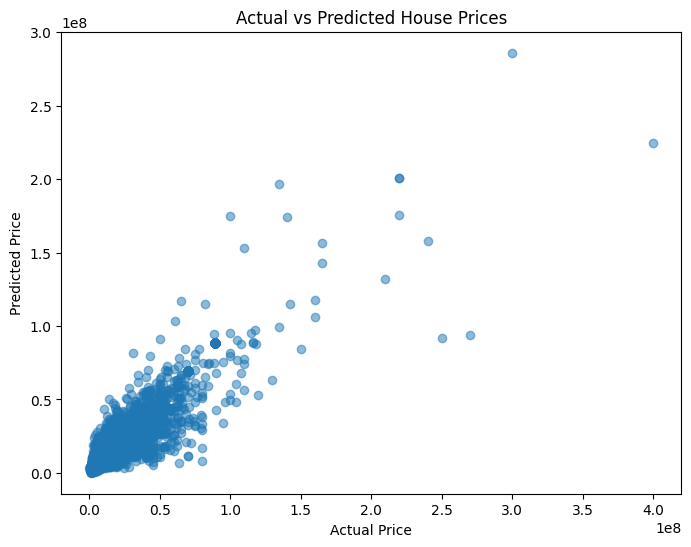

In [55]:
# Actual vs Predicted

best_pred = gb_model.predict(X_test)

plt.figure(figsize=(8,6))

plt.scatter(y_test, best_pred, alpha=0.5)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted House Prices")

plt.show()

### Observation

- Most predicted values are close to the actual prices.
- The model successfully captures the relationship between the input features and house prices.
- A few outliers remain, which is expected in real-world real estate datasets.


# ## Cross Validation

To evaluate the robustness of the selected model, 5-Fold Cross Validation was performed using a shuffled K-Fold strategy.

The model achieved a mean **R² score of approximately 0.884**, indicating stable performance and good generalization across different data splits.


In [58]:
from sklearn.model_selection import KFold

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    gb_model,
    X,
    y,
    cv=cv,
    scoring="r2",
    n_jobs=-1
)
print("Cross Validation Scores:")
print(scores)

print("\nAverage R²:", scores.mean())

Cross Validation Scores:
[0.88237829 0.88722835 0.88272087 0.89353488 0.87626735]

Average R²: 0.8844259482529507


# ## Export the Final Model

The best-performing model is exported using Joblib.

This allows the trained model to be reused later without retraining.


In [61]:
joblib.dump(
    gb_model,
    "house_price.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


In [62]:
locations = sorted(
    df["location_grouped"].unique()
)

with open(
    "locations.json",
    "w"
) as f:

    json.dump(
        locations,
        f,
        indent=4
    )

print("Locations Saved Successfully")

Locations Saved Successfully


In [63]:
# Load Model Again

loaded_model = joblib.load(
    "house_price.pkl"
)

print(type(loaded_model))

<class 'sklearn.pipeline.Pipeline'>


In [64]:
# Test Prediction

sample = X_test.iloc[[0]]

prediction = loaded_model.predict(sample)

print("Predicted Price :", prediction[0])

print("Actual Price    :", y_test.iloc[0])

Predicted Price : 4455922.798420991
Actual Price    : 3500000.0


# ## Project Conclusion

This project successfully developed a complete machine learning pipeline for house price prediction.

The workflow included:

- Data loading and inspection.
- Exploratory Data Analysis (EDA).
- Data cleaning and feature engineering.
- Model training and comparison.
- Performance evaluation.
- Exporting the best model.

Among all evaluated models, **Gradient Boosting Regressor** achieved the highest predictive performance with an **R² score of approximately 0.882**, making it the most suitable model for this task.


In [66]:
from google.colab import files

files.download("house_price.pkl")
files.download("locations.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>